In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/content/crop_yield.csv')

In [5]:
df = df.dropna()   # remove missing values
print(df)

              Crop  Crop_Year       Season           State    Area  \
0         Arecanut       1997  Whole Year            Assam   73814   
1        Arhar/Tur       1997  Kharif                Assam    6637   
2      Castor seed       1997  Kharif                Assam     796   
3         Coconut        1997  Whole Year            Assam   19656   
4     Cotton(lint)       1997  Kharif                Assam    1739   
...            ...        ...          ...             ...     ...   
1985     Arhar/Tur       2006  Kharif       Andhra Pradesh  395644   
1986     Arhar/Tur       2006  Rabi         Andhra Pradesh    5606   
1987         Bajra       2006  Kharif       Andhra Pradesh   48995   
1988         Bajra       2006  Rabi         Andhra Pradesh   12081   
1989        Banana       2006  Whole Year   Andhra Pradesh   50286   

      Production  Annual_Rainfall   Fertilizer  Pesticide        Yield  
0          56708           2051.4   7024878.38   22882.34     0.796087  
1           4

In [ ]:
df.fillna(0, inplace=True)
print(df)

              Crop  Crop_Year       Season           State    Area  \
0         Arecanut       1997  Whole Year            Assam   73814   
1        Arhar/Tur       1997  Kharif                Assam    6637   
2      Castor seed       1997  Kharif                Assam     796   
3         Coconut        1997  Whole Year            Assam   19656   
4     Cotton(lint)       1997  Kharif                Assam    1739   
...            ...        ...          ...             ...     ...   
1985     Arhar/Tur       2006  Kharif       Andhra Pradesh  395644   
1986     Arhar/Tur       2006  Rabi         Andhra Pradesh    5606   
1987         Bajra       2006  Kharif       Andhra Pradesh   48995   
1988         Bajra       2006  Rabi         Andhra Pradesh   12081   
1989        Banana       2006  Whole Year   Andhra Pradesh   50286   

      Production  Annual_Rainfall   Fertilizer  Pesticide        Yield  
0          56708           2051.4   7024878.38   22882.34     0.796087  
1           4

In [6]:
year = df['Crop_Year']
production = df['Production']
rainfall = df['Annual_Rainfall']
print(year)
print(production)
print(rainfall)

0       1997
1       1997
2       1997
3       1997
4       1997
        ... 
1985    2006
1986    2006
1987    2006
1988    2006
1989    2006
Name: Crop_Year, Length: 1990, dtype: int64
0           56708
1            4685
2              22
3       126905000
4             794
          ...    
1985       157669
1986         3174
1987        39988
1988         6986
1989      1224106
Name: Production, Length: 1990, dtype: int64
0       2051.4
1       2051.4
2       2051.4
3       2051.4
4       2051.4
         ...  
1985     845.2
1986     845.2
1987     845.2
1988     845.2
1989     845.2
Name: Annual_Rainfall, Length: 1990, dtype: float64


In [7]:
print(df.columns)

Index(['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production',
       'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield'],
      dtype='object')


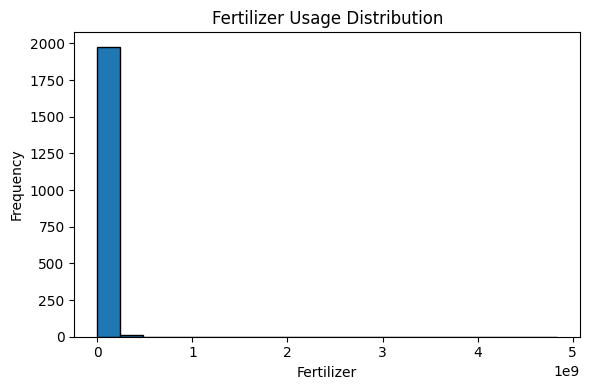

In [10]:
plt.figure(figsize=(6,4))
plt.hist(df['Fertilizer'], bins=20, edgecolor='black')
plt.title("Fertilizer Usage Distribution")
plt.xlabel("Fertilizer")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

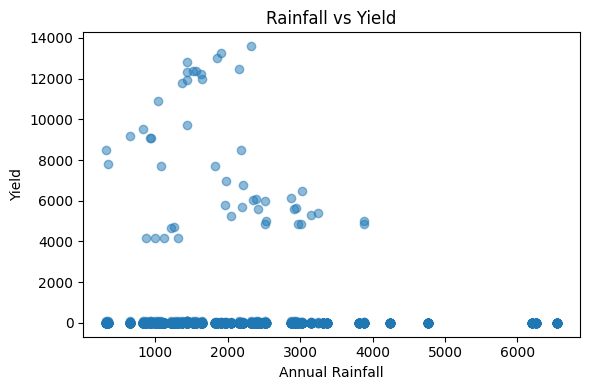

In [13]:
plt.figure(figsize=(6,4))
plt.scatter(df['Annual_Rainfall'], df['Yield'], alpha=0.5)
plt.title("Rainfall vs Yield")
plt.xlabel("Annual Rainfall")
plt.ylabel("Yield")
plt.tight_layout()
plt.show()

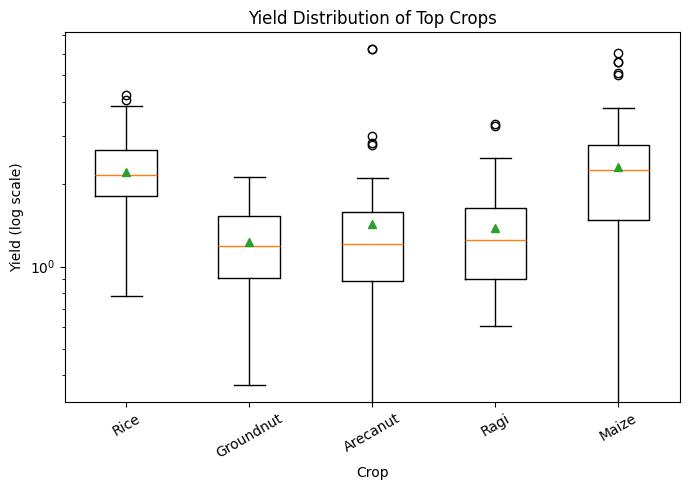

In [18]:


df['Yield'] = pd.to_numeric(df['Yield'], errors='coerce')
df = df.dropna(subset=['Yield'])

top = df['Crop'].value_counts().head(5).index

data = [df[df['Crop']==c]['Yield'] for c in top]

plt.figure(figsize=(7,5))
plt.boxplot(data, tick_labels=top, showmeans=True)

plt.yscale('log')
plt.title("Yield Distribution of Top Crops")
plt.xlabel("Crop")
plt.ylabel("Yield (log scale)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

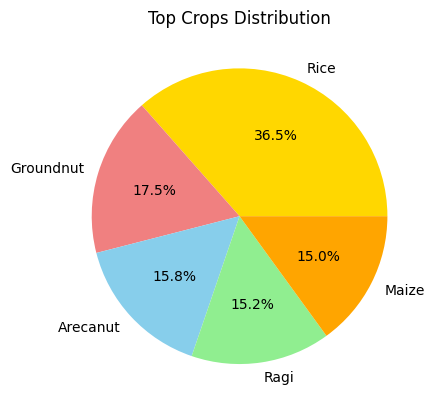

In [24]:


top = df['Crop'].value_counts().head(5)

plt.pie(top, labels=top.index, autopct='%1.1f%%',
        colors=['gold','lightcoral','skyblue','lightgreen','orange'])

plt.title("Top Crops Distribution")
plt.show()

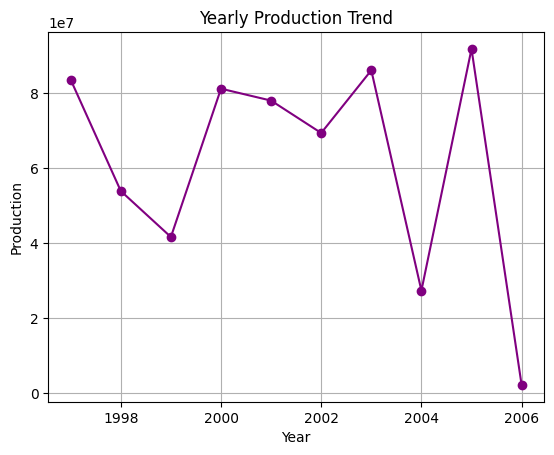

In [25]:


year_prod = df.groupby('Crop_Year')['Production'].sum()

plt.plot(year_prod.index, year_prod.values,
         marker='o', color='purple')

plt.title("Yearly Production Trend")
plt.xlabel("Year")
plt.ylabel("Production")
plt.grid(True)
plt.show()

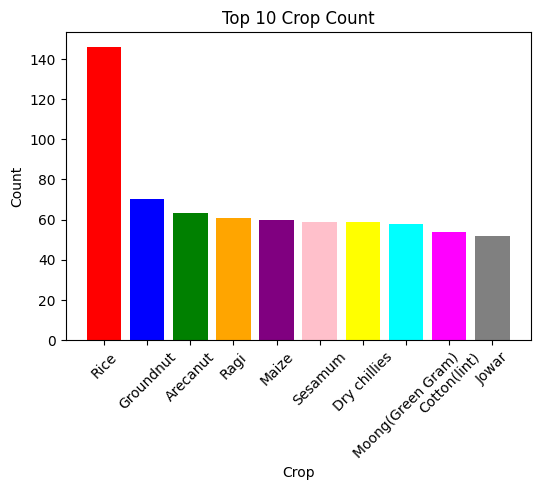

In [26]:


counts = df['Crop'].value_counts().head(10)

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values,
        color=['red','blue','green','orange','purple','pink','yellow','cyan','magenta','grey'])

plt.title("Top 10 Crop Count")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()